# Week 8 - E-Commerce Order Analytics System

### MINI PROJECT 

This project demonstrates an end-to-end data engineering workflow for an e-commerce order analytics system. The project covers synthetic data generation, data cleaning, validation, PostgreSQL integration, SQL analytics, reporting, and edge case handling using Python and SQL.

## Project Objective

The objective of this project is to build a complete data analytics pipeline for an e-commerce system.

The workflow includes:

- Generating synthetic datasets
- Introducing realistic data quality issues
- Cleaning and validating data
- Loading data into PostgreSQL
- Performing SQL-based business analysis
- Generating analytical reports
- Handling common edge cases

## Technologies Used

- Python
- Pandas
- PostgreSQL
- SQLAlchemy
- psycopg2
- Faker
- SQL
- Jupyter Notebook

## Project Workflow

The overall workflow followed in this project is shown below:

Synthetic Data Generation ->  Dirty Data Creation ->  Data Cleaning -> Data Validation -> PostgreSQL Database -> SQL Analytics -> Business Reporting


## PROJECT CONFIGURATION

In [ ]:
from pathlib import Path

import pandas as pd
from scripts import (
    data_generation,
    data_cleaning,
    data_validation
)

In [ ]:
PROJECT_ROOT = Path("..")

RAW_DATA_PATH = PROJECT_ROOT / "Data" / "raw"

CLEANED_DATA_PATH = PROJECT_ROOT / "Data" / "cleaned"

REPORT_PATH = PROJECT_ROOT / "Data" / "reports"

print("Project configuration loaded successfully.")

## Data Generation

In this step, I generated the synthetic datasets required for the project. The datasets include customers, products, orders and order items. Separate dirty datasets were also created to simulate common data quality issues.

In [ ]:
print("Generating datasets...")

data_generation.main()

In [ ]:
customers = pd.read_csv(
    RAW_DATA_PATH / "customers.csv"
)

products = pd.read_csv(
    RAW_DATA_PATH / "products.csv"
)

orders = pd.read_csv(
    RAW_DATA_PATH / "orders.csv"
)

order_items = pd.read_csv(
    RAW_DATA_PATH / "order_items.csv"
)

In [ ]:
print("Customers")
display(customers.head())

print("Products")
display(products.head())

In [ ]:
print("Orders")
display(orders.head())

print("Order Items")
display(order_items.head())

In [ ]:
dataset_summary = pd.DataFrame({

    "Dataset": [
        "Customers",
        "Products",
        "Orders",
        "Order Items"
    ],

    "Records": [
        len(customers),
        len(products),
        len(orders),
        len(order_items)
    ]

})

dataset_summary

### Observation

- All four datasets were generated successfully.
- Separate raw datasets were created for further processing.
- The generated datasets follow the required project schema.

## Dirty Data Creation

To simulate real-world scenarios, intentional data quality issues were introduced into the raw datasets. These include invalid emails, duplicate records, inconsistent product names, missing customer IDs and negative quantities.

In [ ]:
customers_dirty = pd.read_csv(
    RAW_DATA_PATH / "customers_dirty.csv"
)

products_dirty = pd.read_csv(
    RAW_DATA_PATH / "products_dirty.csv"
)

orders_dirty = pd.read_csv(
    RAW_DATA_PATH / "orders_dirty.csv"
)

order_items_dirty = pd.read_csv(
    RAW_DATA_PATH / "order_items_dirty.csv"
)

In [ ]:
print("Customers (Dirty)")
display(customers_dirty.head())

print("Products (Dirty)")
display(products_dirty.head())

In [ ]:
print("Orders (Dirty)")
display(orders_dirty.head())

print("Order Items (Dirty)")
display(order_items_dirty.head())

### Observation

- Dirty datasets were created successfully.
- The introduced issues will be handled during the data cleaning step.

## Data Cleaning

The dirty datasets were cleaned before loading them into the database.

The cleaning process included handling invalid email addresses, removing duplicate records, standardizing product names, fixing missing customer IDs and correcting inconsistent date formats.

In [ ]:
customers_cleaned = pd.read_csv(
    CLEANED_DATA_PATH / "customers_cleaned.csv"
)

products_cleaned = pd.read_csv(
    CLEANED_DATA_PATH / "products_cleaned.csv"
)

orders_cleaned = pd.read_csv(
    CLEANED_DATA_PATH / "orders_cleaned.csv"
)

order_items_cleaned = pd.read_csv(
    CLEANED_DATA_PATH / "order_items_cleaned.csv"
)

In [ ]:
print("Cleaned Customer Dataset")
display(customers_cleaned.head())

print("Cleaned Product Dataset")
display(products_cleaned.head())

In [ ]:
cleaning_report = pd.read_csv(
    REPORT_PATH / "data_cleaning_report.csv"
)

cleaning_report

### Observation

- Invalid records were handled successfully.
- Product names were standardized.
- Missing customer IDs were updated.
- The cleaned datasets were saved for database loading.

## Data Validation

After cleaning, validation checks were performed to verify data quality before loading the datasets into PostgreSQL.

The validation process checked uniqueness, missing values and important business rules.

In [ ]:
validation_report = pd.read_csv(
    REPORT_PATH / "data_validation_report.csv"
)

validation_report

In [ ]:
order_items_cleaned[
    order_items_cleaned["quantity"] < 0
].head()

### Observation

- Validation checks completed successfully.
- Negative quantities were intentionally preserved because they represent returned products.
- The datasets were ready for database loading.

## PostgreSQL Database

The cleaned datasets were loaded into PostgreSQL using SQLAlchemy and Pandas.

Four tables were created in the database:

- customers
- products
- orders
- order_items

The database was used to perform all SQL analysis required in this project.

In [ ]:
print("Database Name : ecommerce_analytics_db")

print("Tables Loaded Successfully")

tables = pd.DataFrame({

    "Table Name": [
        "customers",
        "products",
        "orders",
        "order_items"
    ]

})

tables

### Observation

- All cleaned datasets were loaded successfully.
- Foreign key relationships were maintained.
- The PostgreSQL database was ready for SQL analysis.

## SQL Analytics

After loading the cleaned datasets into PostgreSQL, SQL queries were executed to analyze the business data.

The SQL implementation is organized into three separate files:

- `basic_queries.sql`
- `intermediate_queries.sql`
- `advanced_queries.sql`

The queries cover revenue analysis, customer analysis, product performance, return analysis and advanced SQL concepts such as window functions and CTEs.

Some representative query outputs are shown below.

In [ ]:
sql_summary = pd.DataFrame({

    "SQL File": [
        "basic_queries.sql",
        "intermediate_queries.sql",
        "advanced_queries.sql"
    ],

    "Topics Covered": [
        "Revenue, Customers, Monthly Orders",
        "Returns, Customer Behaviour, Category Analysis",
        "Window Functions, Ranking, Cohort Style Analysis"
    ]

})

sql_summary

### Sample SQL Analysis

Below are a few representative query outputs from the SQL analysis. The complete SQL implementation is available in the `sql` folder.

### Query 1 - Total Revenue by Category

This query calculates the total revenue generated by each product category.

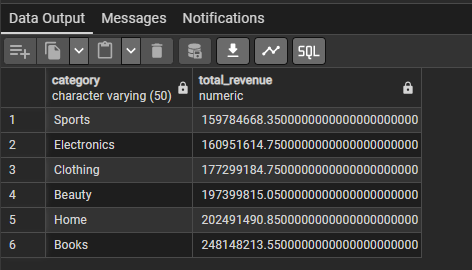

**Observation**

- Books generated the highest revenue in the dataset.
- Sports generated the lowest revenue among the available categories.

### Query 2 - Top 10 Customers by Revenue

This query identifies the customers who generated the highest revenue based on their orders.

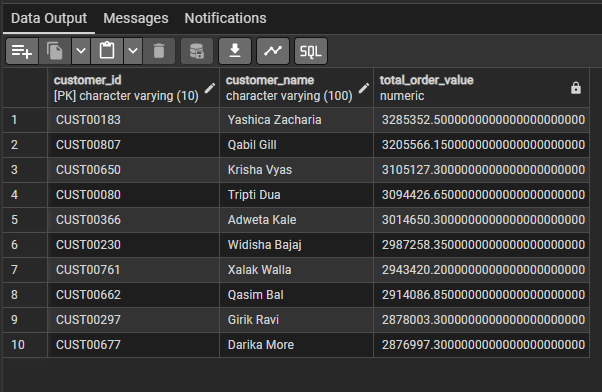

**Observation**

- The query helps identify high-value customers.
- These customers can be targeted for loyalty programs and personalized offers.

### Query 4 - Customers Without Delivered Orders

This query finds customers who placed orders but never had an order with the status **DELIVERED**.

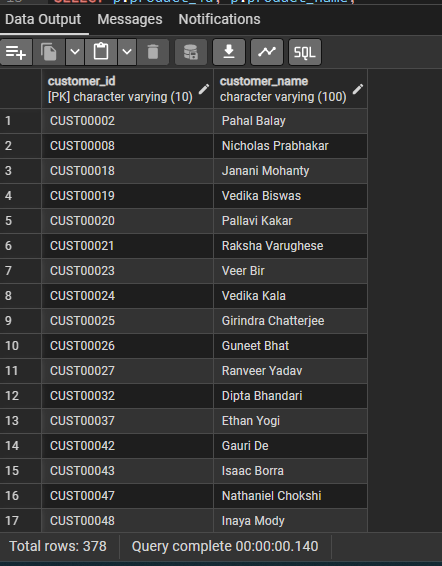

**Observation**

- A number of customers have placed orders but never received a delivered order.
- This type of analysis can help identify delivery or customer service issues.

### Query 7 - Running Revenue by Region

This query uses a window function to calculate the running total of revenue for each region based on the order date.

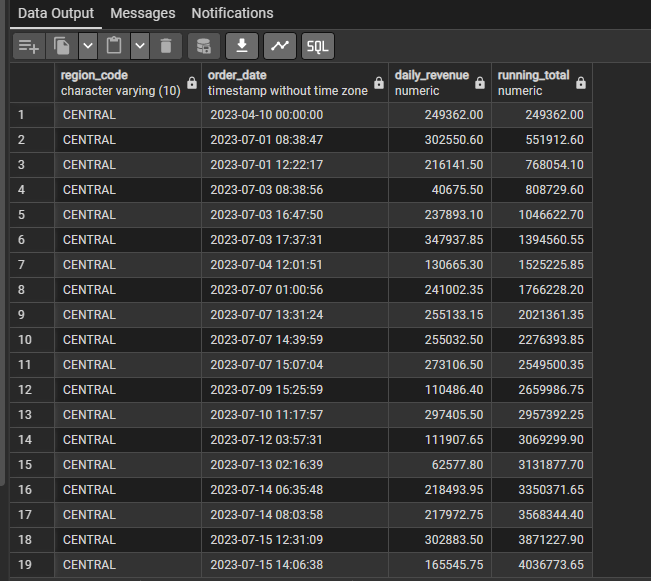

**Observation**

- Window functions make it possible to calculate cumulative revenue without using complex subqueries.
- The running total helps understand how revenue grows over time within each region.

### Summary

The SQL analysis covered basic, intermediate and advanced business queries. These queries helped analyze customer behavior, product performance, revenue trends, returns and advanced analytical metrics using PostgreSQL.

The complete SQL implementation is available in the `sql` folder of the project.

## Python Reporting

A command-line reporting tool was developed as part of this project.

The tool accepts:
- Report type
- Date range

It then connects to the PostgreSQL database and generates:
- Total Orders
- Total Revenue
- Unique Customers
- Top 3 Products
- Previous Period Comparison

The implementation is available in `scripts/reporting.py` and `scripts/analytics.py`.

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

In [4]:
from scripts.analytics import (
    get_total_orders,
    get_total_revenue,
    get_unique_customers,
    get_top_products
)

In [ ]:
# Choose any date range that exists in data
start_date = "2023-01-01"
end_date = "2026-12-31"

In [6]:
print("Total Orders")
get_total_orders(start_date, end_date)

Total Orders


,total_orders
0,5000


In [7]:
print("Total Revenue")
get_total_revenue(start_date, end_date)

Total Revenue


,total_revenue
0,1.080224e+09


In [8]:
print("Unique Customers")
get_unique_customers(start_date, end_date)

Unique Customers


,unique_customers
0,997


In [9]:
print("Top 3 Products")
get_top_products(start_date, end_date)

Top 3 Products


,product_name,total_revenue
0,Nike Decor,18309991.65
1,Samsung Self Help,18173342.90
2,Adidas Kitchen,17866362.70


## Project Summary

The project successfully implemented a complete data analytics workflow for an e-commerce order management system.

The major tasks completed during the project include:

- Synthetic data generation
- Dirty data creation
- Data cleaning
- Data validation
- PostgreSQL database integration
- SQL business analysis
- Python-based reporting
- Edge case validation

## Learning Outcomes

During this project, I learned how to:

- Generate realistic synthetic datasets using Python and Faker.
- Clean and validate data before loading it into a database.
- Load datasets into PostgreSQL using SQLAlchemy.
- Write SQL queries to solve business problems.
- Use window functions, CTEs and ranking functions.
- Build a simple reporting module using Python and SQL.
- Organize a project into reusable Python scripts.

## Conclusion

This project helped me understand the complete workflow of a small data engineering project, starting from data generation and ending with business reporting.

I gained practical experience in Python, PostgreSQL and SQL by implementing each step of the pipeline instead of only studying the concepts. The project also improved my understanding of data quality, SQL analytics and project organization.